This notebook examines a baseline model for forecasting store sales data. During the initial EDA of average daily sales across stores, it was observed that there is a strong weekly seasonal pattern in the data, so the baseline model will be a seasonal model that uses the previous week's values as the forecasts.

## Evaluate model

In [1]:
from ssdf.config import STATIC_FEATURES
from ssdf.training import eval, train

/home/tiloye/projects/store-sales-demand-forecasting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
forecaster = train.get_model()
df = train.get_data()

Splitting data into train and test sets...
Logging the training data to MLflow...


/home/tiloye/projects/store-sales-demand-forecasting/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Evaluating forecaster on 5 validation set(s)...
Average RMSLE across all folds: 0.5767088128565219
Standard deviation of RMSLE across all folds: 0.02207238547472891
Plotting average daily sales for random stores from cross validation result


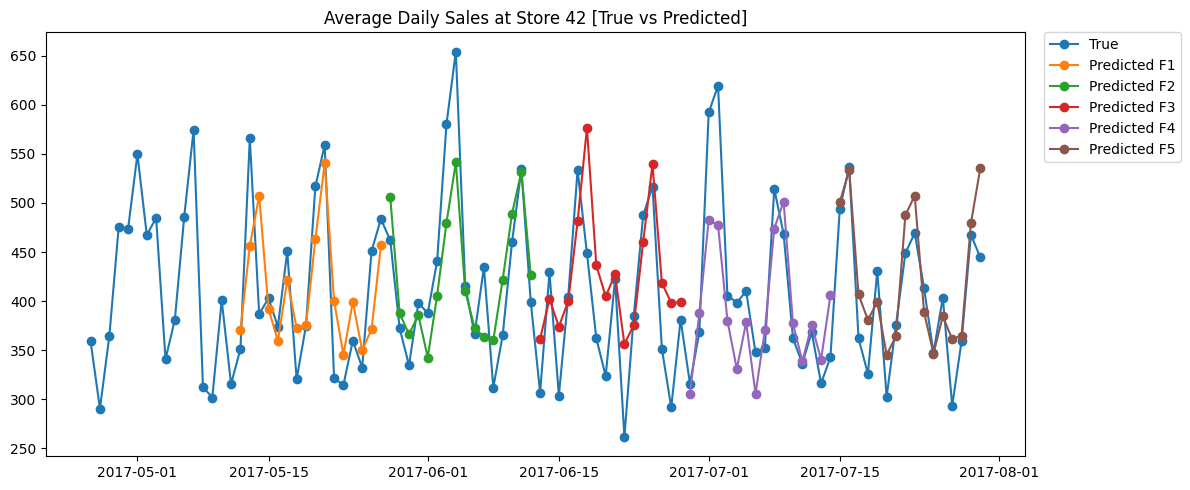

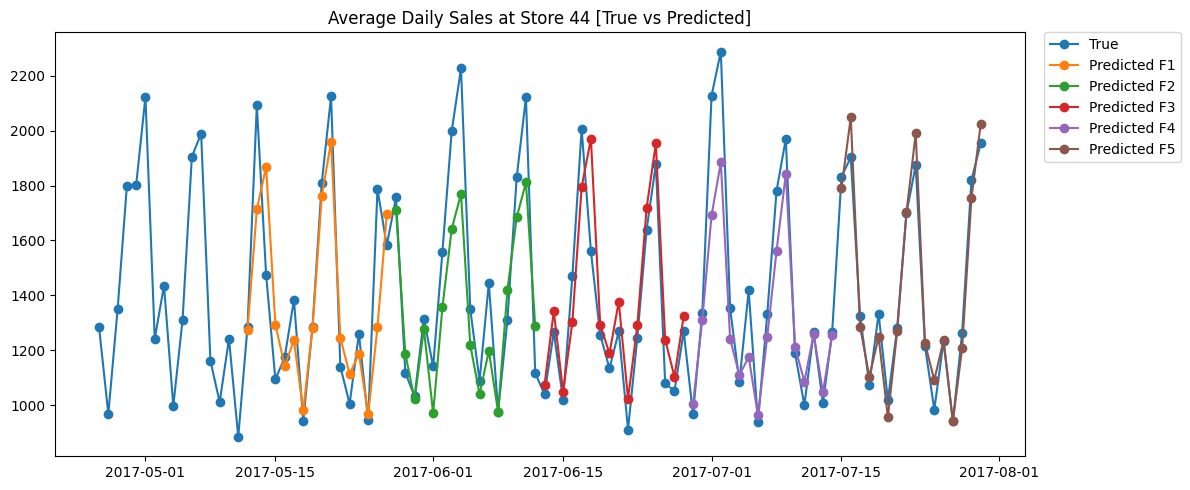

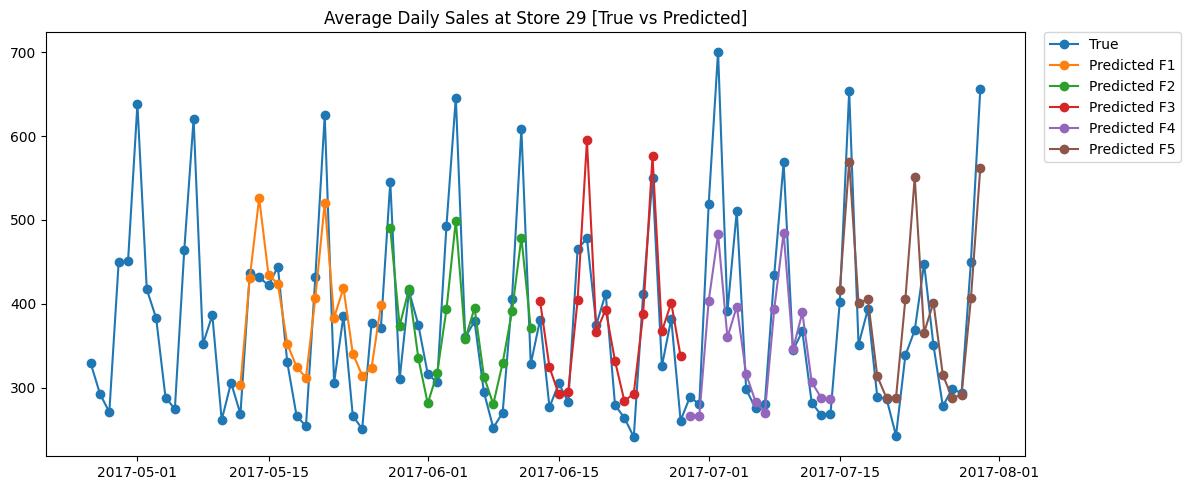

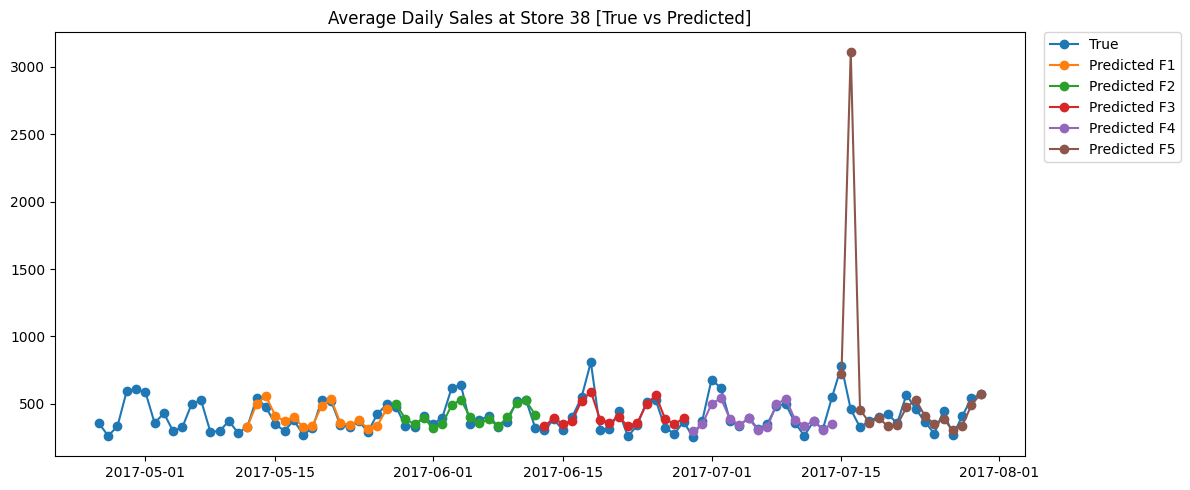

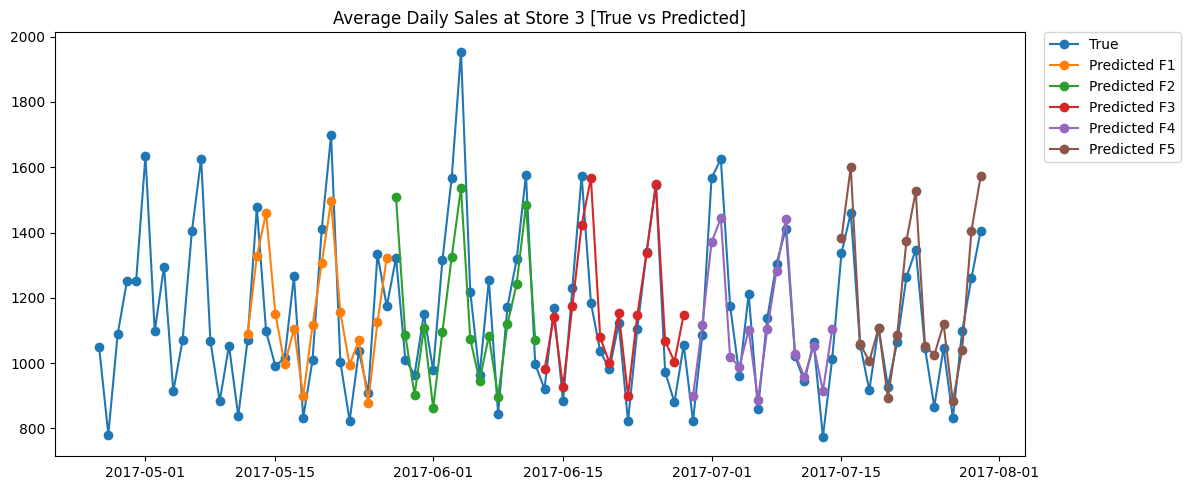

Evaluating forecaster on test set...
Test RMSLE: 0.5920620514277078
Plotting average daily sales for random stores from test set...


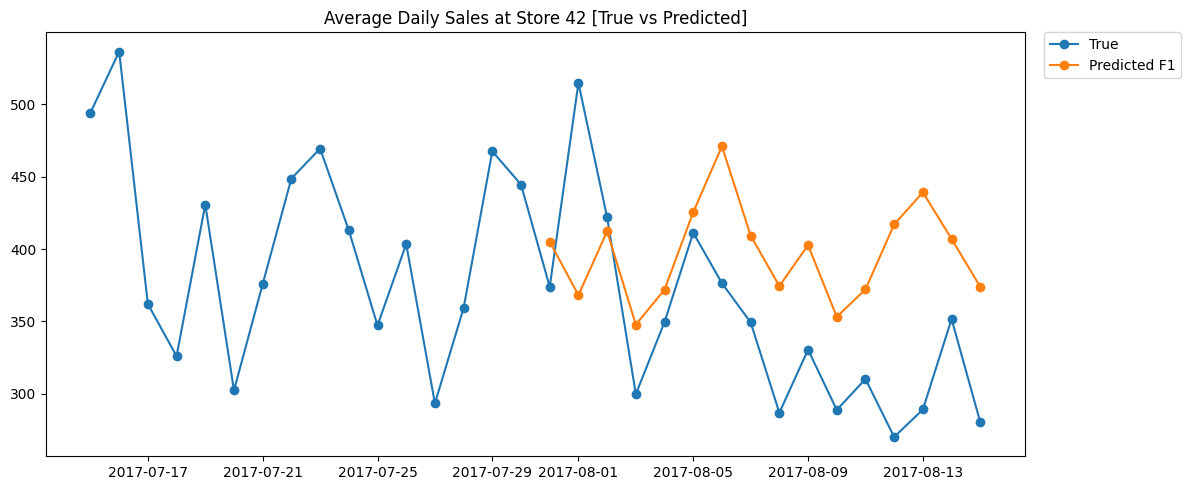

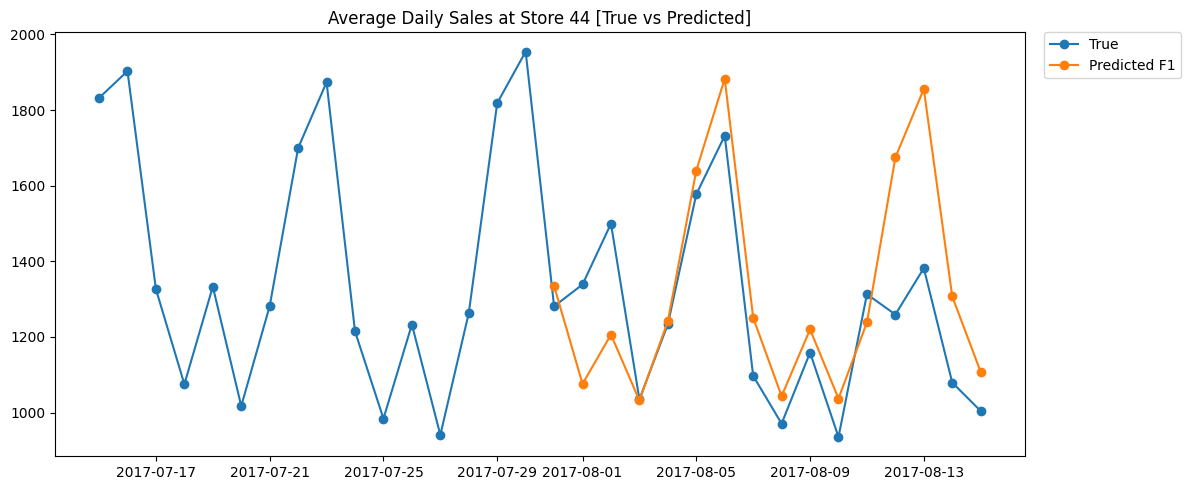

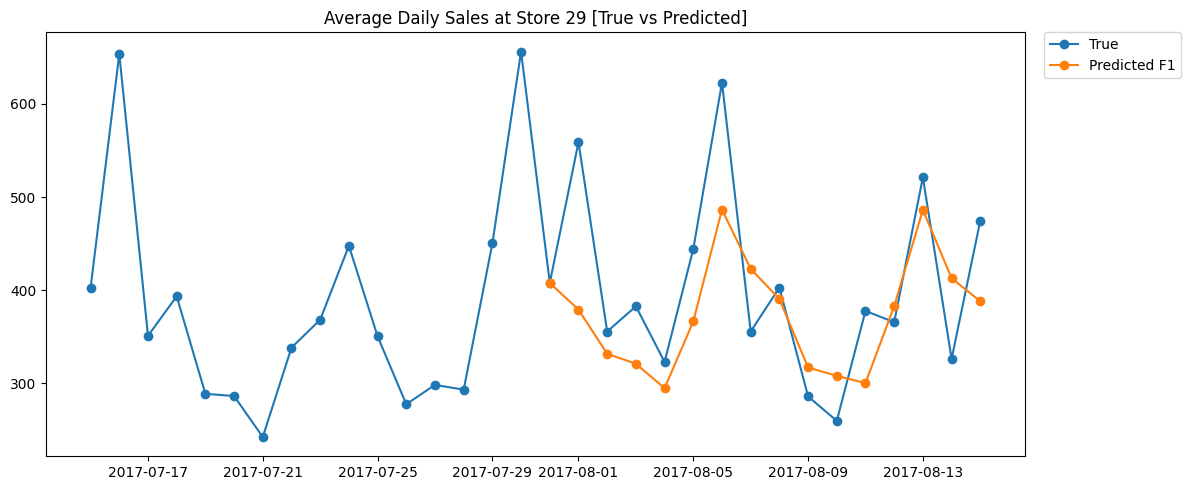

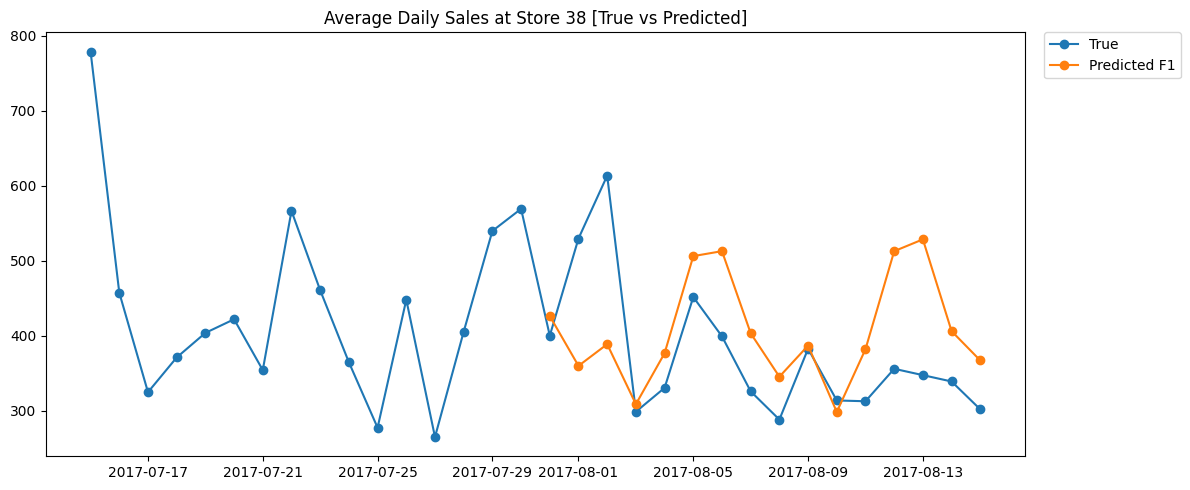

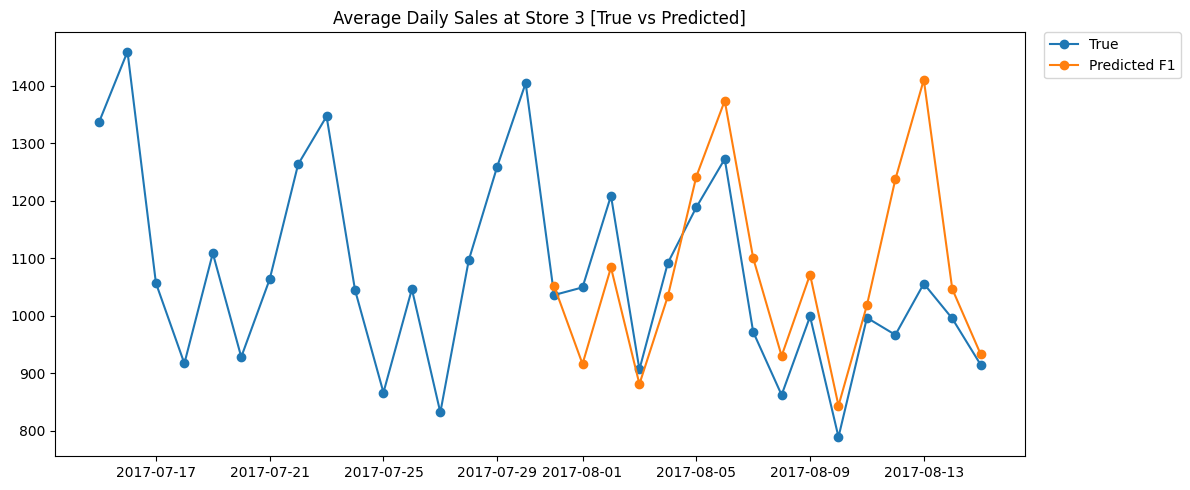

🏃 View run useful-shoat-939 at: http://localhost:5000/#/experiments/1/runs/33d7e18d0b1e46239abe58b0cddb949e
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [3]:
result, mlflow_run =  eval.run(forecaster, df, static_features=STATIC_FEATURES, k=5)

## Train model on full Data

In [4]:
run_id = mlflow_run.info.run_id

In [5]:
fitted_forecaster, train_run = train.run(
    df, static_features=STATIC_FEATURES, exp_run_id=run_id
)

Logging training data to MLflow


/home/tiloye/projects/store-sales-demand-forecasting/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Training the forecaster


2026/04/27 11:47:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training complete
Logging the trained model to MLflow


2026/04/27 11:47:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run useful-shoat-939 at: http://localhost:5000/#/experiments/1/runs/33d7e18d0b1e46239abe58b0cddb949e
🧪 View experiment at: http://localhost:5000/#/experiments/1


## Generate predictions

In [6]:
import mlflow
from ssdf.inference import predict

In [7]:
model_id = mlflow.get_run(train_run.info.run_id).outputs.model_outputs[0].model_id
model_uri = f"models:/{model_id}"
model = predict.run(model_uri)

Loading model and generating forecasts...


Successfully generated forecasts
Saving forecasts...
Successfully saved forecasts
